# r/vanlife

#### Reddit group description:
For people that live a carefree, mobile, and active lifestyle on the road. Share rig images, helpful websites, road stories, tips and tricks for camping locations.

Created Mar 2, 2013
Public 283K Members
Top 1% Rank by size 

### Topic Modeling

In [1]:
import pandas as pd
import re
import gensim
import pyLDAvis
import pyLDAvis.gensim_models
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /Users/admin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/admin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
# Load and examine data
df = pd.read_csv('Data/reddit/vanlife.csv')
print(f"Loaded {len(df)} comments")
print(f"Columns: {df.columns.tolist()}")
print(f"First few comments:")
for i in range(3):
    print(f"{i+1}: {df.iloc[i, 0][:100]}...")

Loaded 6886 comments
Columns: ['0']
First few comments:
1: Solar Panels Recommendations...
2: Cancel renogy. Same quality and manufacturing for 50% of the price are available.  ...
3: I was recommended shingled solar panels from a discount type of retailer. Not sure they are actually...


In [3]:
# Clean and prepare text
def clean_text(text):
    if not isinstance(text, str) or text in ['[deleted]', '[removed]', '']:
        return ""
    
    # Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Remove punctuation, numbers, etc.
    text = re.sub(r"[^A-Za-z\s]", "", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

# Apply cleaning
comments = df.iloc[:, 0].apply(clean_text)
comments = comments[comments.str.len() > 10]  # Remove very short comments
print(f"After cleaning: {len(comments)} comments")

After cleaning: 6615 comments


In [4]:
# Tokenize and remove stopwords
swords = stopwords.words('english')

# Remove punctuation from stopwords to match your cleaned text
swords_clean = []
for word in swords:
    # Apply same cleaning as clean_text function
    clean_word = re.sub(r"[^A-Za-z\s]", "", word)
    if clean_word and len(clean_word) > 0:
        swords_clean.append(clean_word.lower())

# Remove duplicates and empty strings
swords_clean = list(set([word for word in swords_clean if word]))
swords_clean = sorted(swords_clean)

print(f"Original stopwords: {len(swords)}")
# print(swords)
print(f"Cleaned stopwords: {len(swords_clean)}")
# print(swords_clean)

# Add specific stopwords
reddit_stopwords = ['reddit', 'edit', 'update', 'deleted', 'removed', 'comment', 'post', 'thread']
additional_stopwords = ['lets', 'thats', 'people', 'even', 'time', 'way', 'thats', 'youre', 'much', 'would', 'could', 'get', 'one', 'also', 'really', 'think', 'know', 'like']

swords_clean.extend(reddit_stopwords + additional_stopwords)

print(f"Extended stopwords: {len(swords_clean)}")
# print(swords_clean)

# Tokenize
wordlists = []
for comment in comments:
    words = [word for word in word_tokenize(comment.lower()) 
            if word not in swords_clean 
            and len(word) > 0
            and word.isalpha()]
    
    wordlists.append(words)

print(f"Prepared {len(wordlists)} comments for modeling")

Original stopwords: 198
Cleaned stopwords: 196
Extended stopwords: 222
Prepared 6615 comments for modeling


In [5]:
# Analyze word frequencies
all_words = [word for wordlist in wordlists for word in wordlist]
word_freq = Counter(all_words)

print("Top 20 most common words:")
for word, freq in word_freq.most_common(20):
    print(f"{word}: {freq}")

Top 20 most common words:
van: 1812
good: 661
use: 639
need: 629
want: 597
go: 541
work: 524
make: 474
lot: 458
going: 434
see: 402
power: 401
back: 371
battery: 367
got: 363
space: 361
around: 357
solar: 343
something: 338
k: 337


In [6]:
# Run topic model
def run_topic_model(wordlists, num_topics=4, alpha=0.7, eta=0.5):
    dictionary = gensim.corpora.Dictionary(wordlists)
    dictionary.filter_extremes(no_below=2, no_above=0.5)
    corpus = [dictionary.doc2bow(wl) for wl in wordlists]
    
    model = gensim.models.LdaMulticore(
        corpus, 
        id2word=dictionary, 
        num_topics=num_topics,
        alpha=alpha,
        eta=eta,
        random_state=1
    )
    
    return model, corpus, dictionary

# Run the model
model, corpus, dictionary = run_topic_model(wordlists, num_topics=4)


In [7]:
# Display topics
print("Topics found:")
print("=" * 50)

for idx, topic in model.show_topics(formatted=False, num_words=10):
    print(f"\nTopic {idx + 1}:")
    words = [word for word, prob in topic]
    print(f"{', '.join(words)}")


Topics found:

Topic 1:
van, good, use, want, go, need, going, work, make, lot

Topic 2:
van, good, work, use, want, need, see, lot, make, going

Topic 3:
van, need, use, good, want, work, go, make, back, lot

Topic 4:
van, go, want, need, use, good, space, lot, make, going


In [8]:
# Visualize topics
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(model, corpus, dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.003305  0.001562       1        1  26.451563
0     -0.001548  0.001432       2        1  26.354510
2      0.000235 -0.004837       3        1  24.137420
1      0.004618  0.001843       4        1  23.056508, topic_info=         Term         Freq        Total Category  logprob  loglift
483      work   469.000000   469.000000  Default  30.0000  30.0000
1377      new   206.000000   206.000000  Default  29.0000  29.0000
218       see   360.000000   360.000000  Default  28.0000  28.0000
491   windows   181.000000   181.000000  Default  27.0000  27.0000
151       van  1629.000000  1629.000000  Default  26.0000  26.0000
...       ...          ...          ...      ...      ...      ...
58       sure    64.445981   276.889702   Topic4  -6.0937   0.0094
206        go    86.176438   487.763701   Topic4  -5.8031  -0.2662
597     build    65.545091   300.305656   Topic4  -6.0768  -0.0548
67      years    63.737322   277.141989   Topic4  -6.1047  -0.0025
2       solar    63.579907   308.773136   Topic4  -6.1072  -0.1131

[375 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
6558      1  0.140458  absorb
6558      2  0.280916  absorb
6558      3  0.140458  absorb
6558      4  0.421373  absorb
441       1  0.288543      ac
...     ...       ...     ...
67        4  0.230929   years
6933      1  0.278598       z
6933      2  0.557197       z
6933      3  0.278598       z
6933      4  0.278598       z

[1080 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 1, 3, 2])

### Sentiment Analysis

In [9]:
# Sentiment Analysis for Reddit Comments
from textblob import TextBlob
import pandas as pd

# Apply sentiment analysis to your cleaned comments
print("Analyzing sentiment...")
sentiment_scores = [TextBlob(comment).sentiment.polarity for comment in comments]

# Create dataframe with comments and polarity scores
df_sentiment = pd.DataFrame({
    'comment': comments,
    'polarity': sentiment_scores
})

print(f"Analyzed {len(df_sentiment)} comments")
print(f"Sentiment analysis complete!")

# Display basic statistics
print(f"\nSentiment Statistics:")
print(f"Mean polarity: {df_sentiment['polarity'].mean():.3f}")
print(f"Median polarity: {df_sentiment['polarity'].median():.3f}")
print(f"Min polarity: {df_sentiment['polarity'].min():.3f}")
print(f"Max polarity: {df_sentiment['polarity'].max():.3f}")

# Categorize sentiments
df_sentiment['sentiment_category'] = df_sentiment['polarity'].apply(
    lambda x: 'Positive' if x > 0.1 else ('Negative' if x < -0.1 else 'Neutral')
)

print(f"\nSentiment Distribution:")
print(df_sentiment['sentiment_category'].value_counts())

# Show examples
print(f"\nMost Positive Comments:")
print(df_sentiment.nlargest(3, 'polarity')[['comment', 'polarity']])

print(f"\nMost Negative Comments:")
print(df_sentiment.nsmallest(3, 'polarity')[['comment', 'polarity']])

Analyzing sentiment...
Analyzed 6615 comments
Sentiment analysis complete!

Sentiment Statistics:
Mean polarity: 0.126
Median polarity: 0.082
Min polarity: -1.000
Max polarity: 1.000

Sentiment Distribution:
sentiment_category
Positive    3064
Neutral     2916
Negative     635
Name: count, dtype: int64

Most Positive Comments:
                                               comment  polarity
3    Solar is a bit hit and miss We have a watt pan...       1.0
87                Excellent start to deciding van size       1.0
177                                     Awesome set up       1.0

Most Negative Comments:
                                               comment  polarity
405  I dont think theyre prevalent in Arizona NM is...      -1.0
410  They are awful in northern CO where I am Booti...      -1.0
425  Goatheads are something cooked up in hell by S...      -1.0


parking: 156 comments found
sleep: 194 comments found
bathroom: 40 comments found
water: 216 comments found
cook: 116 comments found
police: 26 comments found
noise: 26 comments found
solar: 279 comments found
job: 121 comments found


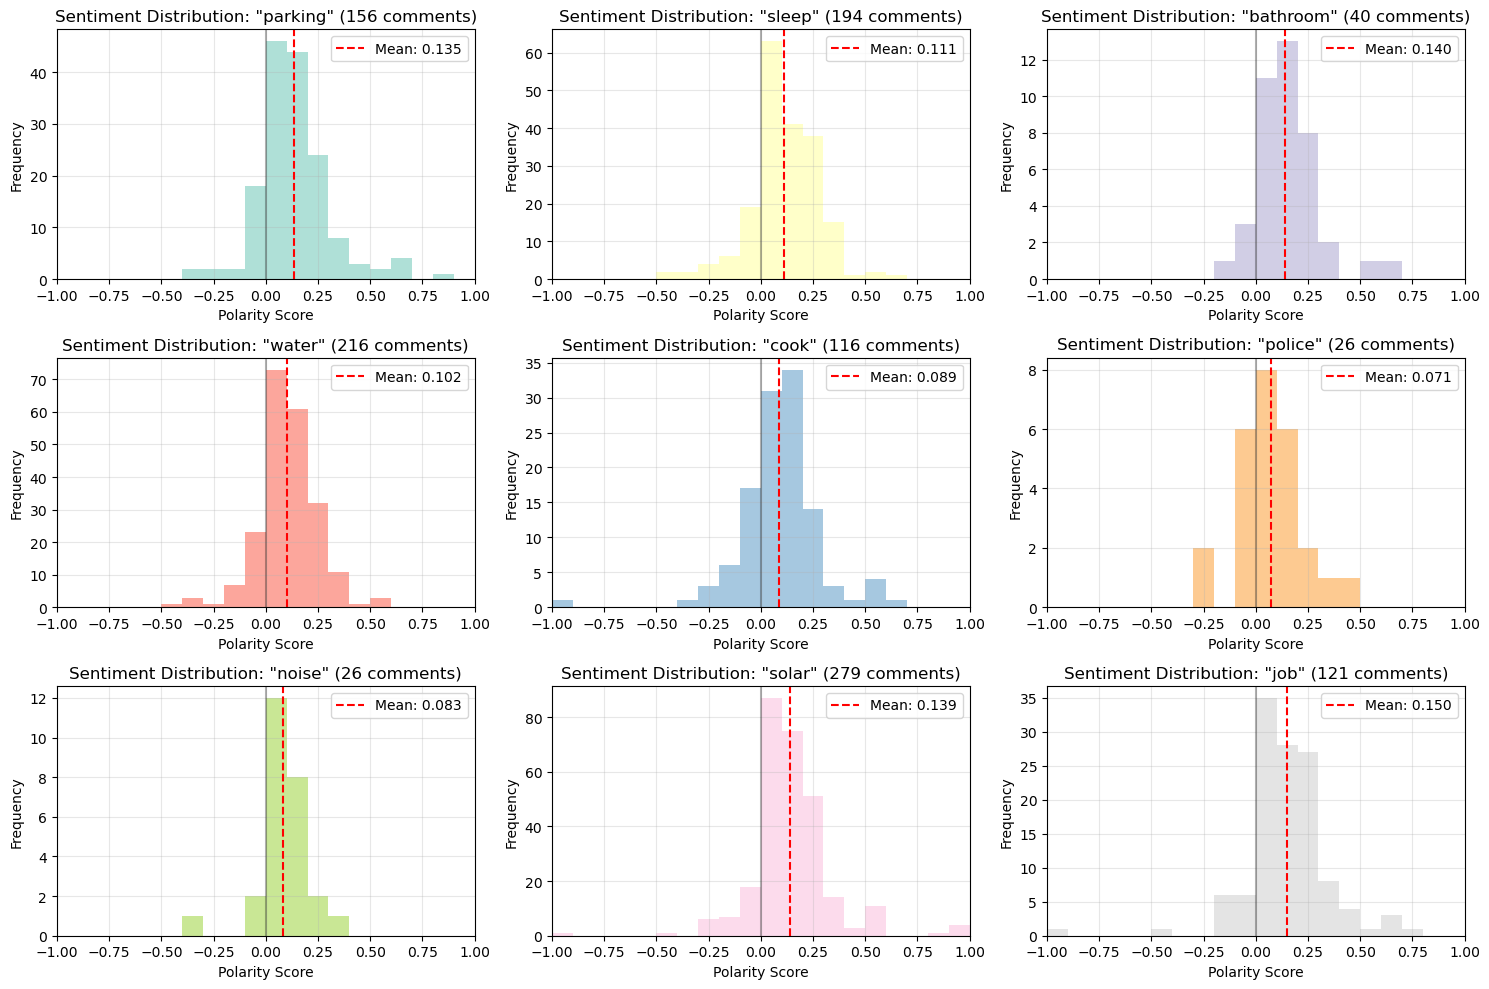

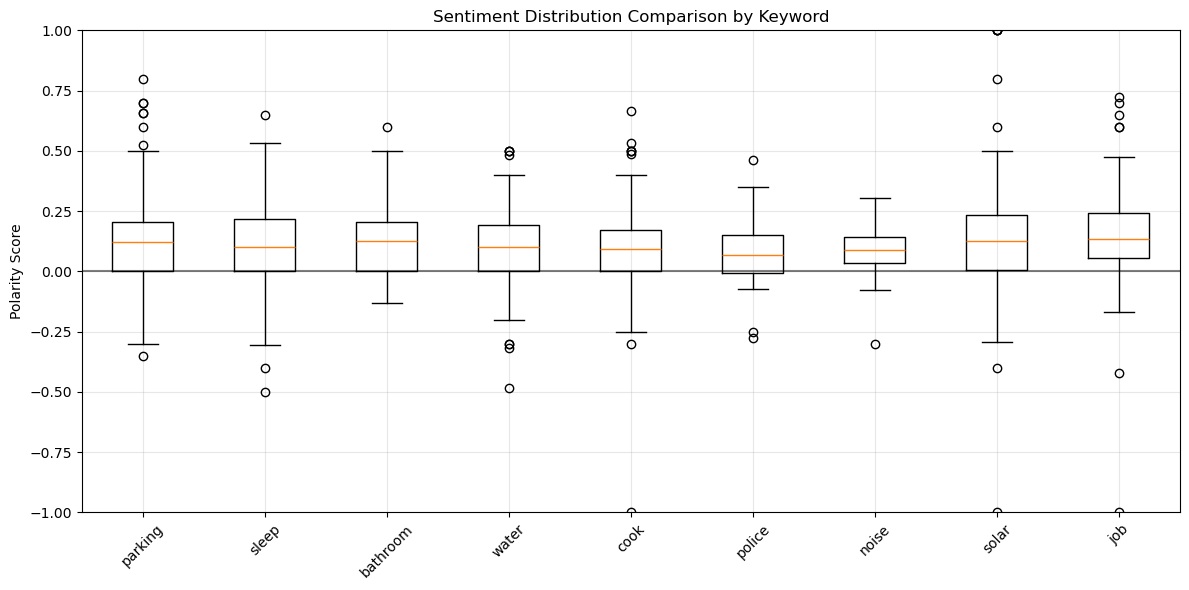

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Define keywords to analyze
keywords = ['parking', 'sleep', 'bathroom', 'water', 'cook', 'police', 'noise', 'solar', 'job']

# Function to find comments containing specific keywords
def get_sentiment_by_keyword(df_sentiment, keyword):
    mask = df_sentiment['comment'].str.contains(keyword, case=False, na=False)
    return df_sentiment[mask]['polarity']

# Collect sentiment data for each keyword
keyword_sentiments = {}
for keyword in keywords:
    sentiments = get_sentiment_by_keyword(df_sentiment, keyword)
    keyword_sentiments[keyword] = sentiments
    print(f"{keyword}: {len(sentiments)} comments found")

# Create subplot for each keyword
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
x_min, x_max = -1.0, 1.0  
bins = np.linspace(x_min, x_max, 21)  

for i, keyword in enumerate(keywords):
    sentiments = keyword_sentiments[keyword]
    
    if len(sentiments) > 0:
        # Create histogram with consistent bins and x-axis
        axes[i].hist(sentiments, bins=bins, alpha=0.7, color=plt.cm.Set3(i))
        axes[i].axvline(sentiments.mean(), color='red', linestyle='--', 
                       label=f'Mean: {sentiments.mean():.3f}')
        axes[i].set_title(f'Sentiment Distribution: "{keyword}" ({len(sentiments)} comments)')
        axes[i].set_xlabel('Polarity Score')
        axes[i].set_ylabel('Frequency')
        axes[i].set_xlim(x_min, x_max)  # Consistent x-axis range
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        
        # Add vertical line at 0 for reference
        axes[i].axvline(0, color='black', linestyle='-', alpha=0.3)
    else:
        axes[i].text(0.5, 0.5, f'No comments found\nfor "{keyword}"', 
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(f'Sentiment Distribution: "{keyword}"')
        axes[i].set_xlim(x_min, x_max)  # Keep same x-axis even for empty plots
        axes[i].set_xlabel('Polarity Score')
        axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Box plot comparison with consistent y-axis
plt.figure(figsize=(12, 6))
sentiment_data = [keyword_sentiments[keyword] for keyword in keywords if len(keyword_sentiments[keyword]) > 0]
labels = [keyword for keyword in keywords if len(keyword_sentiments[keyword]) > 0]

if sentiment_data:
    plt.boxplot(sentiment_data, labels=labels)
    plt.title('Sentiment Distribution Comparison by Keyword')
    plt.ylabel('Polarity Score')
    plt.ylim(x_min, x_max)  # Consistent y-axis range
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No sentiment data found for any keywords")